# GetAround — Exploratory data analysis

Two datasets support this project:

1. **`get_around_delay_analysis.xlsx`** — rentals and their checkout delays; feeds the Streamlit dashboard.
2. **`get_around_pricing_project.csv`** — car characteristics and daily price; feeds the pricing model.

The pricing section is deliberately split in two:

- **decision-driving EDA** — the findings that change a choice in the modelling pipeline (cleaning, encoding, metric);
- **interpretation EDA** — the findings that change nothing in the pipeline, but give a reference frame for reading the model's feature importances afterwards.

In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

PRIMARY, ACCENT, INK = "#6C3FFF", "#FF5A5F", "#1B1340"

In [2]:
# The dataset lives with the dashboard that consumes it: one copy, one source of
# truth, one binary in Git LFS.
DATA = Path("../dashboard/data")

# Check if the file exists - at the beginning of the notebook: a notebook's working directory is not 
# guaranteed, so a missing file here is usually a wrong starting directory rather than a missing dataset.
assert (DATA / "get_around_delay_analysis.xlsx").exists(), (
    f"Datasets not found in {DATA.resolve()} — run this notebook from notebooks/"
)

# we show where we look at the data - in absolute 
print("Data directory:", DATA.resolve())

Data directory: C:\dev\Projets_Certif\Projet_GetAround_ENGptf\dashboard\data


---
## Part 1 — Delay dataset

One row per rental. The questions here are the state of each rental, the check-in type, and above all the **delay at checkout**.

In [3]:
delay = pd.read_excel(DATA / "get_around_delay_analysis.xlsx", sheet_name="rentals_data")
print("Shape:", delay.shape)
delay.head()

Shape: (21310, 7)


,rental_id,car_id,checkin_type,state,delay_at_checkout_in_minutes,previous_ended_rental_id,time_delta_with_previous_rental_in_minutes
0,505000,363965,mobile,canceled,NaN,NaN,NaN
1,507750,269550,mobile,ended,-81.0,NaN,NaN
2,508131,359049,connect,ended,70.0,NaN,NaN
3,508865,299063,connect,canceled,NaN,NaN,NaN
4,511440,313932,mobile,ended,NaN,NaN,NaN


In [4]:
delay.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21310 entries, 0 to 21309
Data columns (total 7 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   rental_id                                   21310 non-null  int64  
 1   car_id                                      21310 non-null  int64  
 2   checkin_type                                21310 non-null  object 
 3   state                                       21310 non-null  object 
 4   delay_at_checkout_in_minutes                16346 non-null  float64
 5   previous_ended_rental_id                    1841 non-null   float64
 6   time_delta_with_previous_rental_in_minutes  1841 non-null   float64
dtypes: float64(3), int64(2), object(2)
memory usage: 1.1+ MB


### Missing values

The `NaN` values are structural rather than defects: a cancelled rental has no checkout delay, and `previous_ended_rental_id` is only filled when the same car was rented immediately before.

In [5]:
missing = delay.isna().sum().to_frame("n_missing")
missing["%"] = (missing["n_missing"] / len(delay) * 100).round(1)
missing

,n_missing,%
rental_id,0,0.0
car_id,0,0.0
checkin_type,0,0.0
state,0,0.0
delay_at_checkout_in_minutes,4964,23.3
previous_ended_rental_id,19469,91.4
time_delta_with_previous_rental_in_minutes,19469,91.4


### Rental state and check-in type

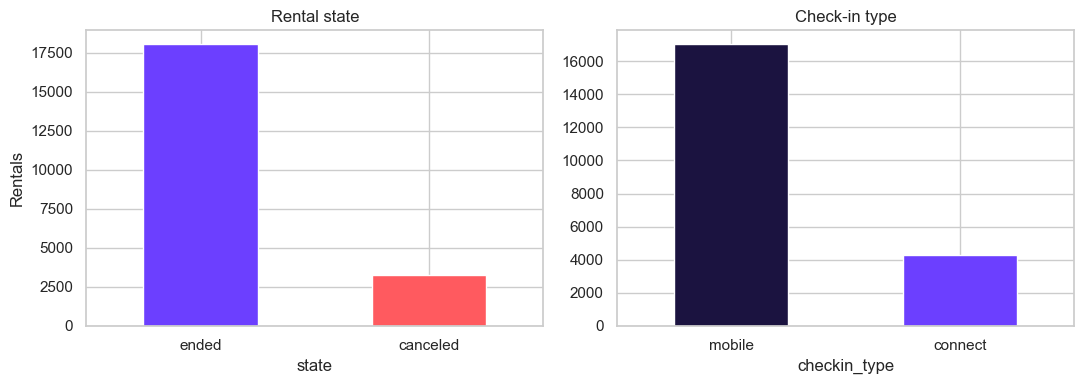

{'ended': 0.847, 'canceled': 0.153}
{'mobile': 0.798, 'connect': 0.202}


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

delay["state"].value_counts().plot.bar(ax=axes[0], color=[PRIMARY, ACCENT], rot=0)
axes[0].set_title("Rental state")
axes[0].set_ylabel("Rentals")

delay["checkin_type"].value_counts().plot.bar(ax=axes[1], color=[INK, PRIMARY], rot=0)
axes[1].set_title("Check-in type")

plt.tight_layout()
plt.show()

print(delay["state"].value_counts(normalize=True).round(3).to_dict())
print(delay["checkin_type"].value_counts(normalize=True).round(3).to_dict())

### Distribution of checkout delays

**Data quality note:** the variable ranges from −22,433 to +71,084 minutes. Those extremes are implausible as returns and are almost certainly logging artefacts, but they are kept in the data — the histogram below is clipped to ±300 minutes for readability only. A negative delay means the car came back early.

raw min / max: -22433.0 / 71084.0
late returns (>0): 57.5%
median lateness when late: 53 min


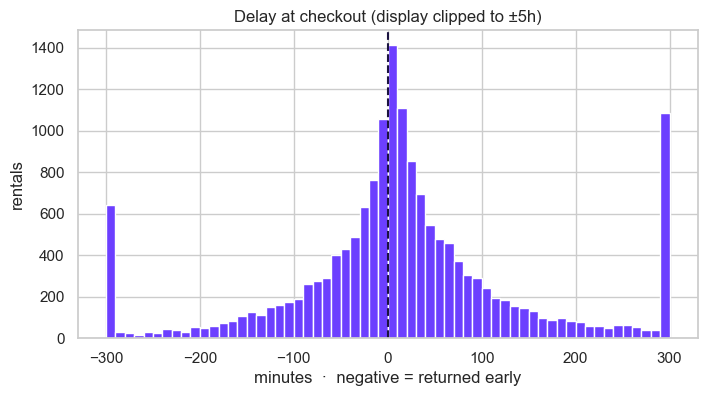

In [7]:
d = delay.loc[delay.state == "ended", "delay_at_checkout_in_minutes"].dropna()

print("raw min / max:", d.min(), "/", d.max())
print(f"late returns (>0): {(d > 0).mean() * 100:.1f}%")
# Median of positive delays only: robust to the extreme values above.
print(f"median lateness when late: {d[d > 0].median():.0f} min")

plt.figure()
# clip() piles the tails onto the bounds — cosmetic; every statistic and every
# simulation downstream uses the raw values.
plt.hist(d.clip(-300, 300), bins=60, color=PRIMARY, edgecolor="white")
plt.axvline(0, color=INK, ls="--")
plt.title("Delay at checkout (display clipped to ±5h)")
plt.xlabel("minutes  ·  negative = returned early")
plt.ylabel("rentals")
plt.show()

### The back-to-back subset

Only rentals with a previous rental of the same car (`previous_ended_rental_id` filled) can be affected by a minimum-delay rule. The proportion of consecutive rentals limits the potential impact of the measure.


Back-to-back rentals: 1841 / 21310 = 8.6%


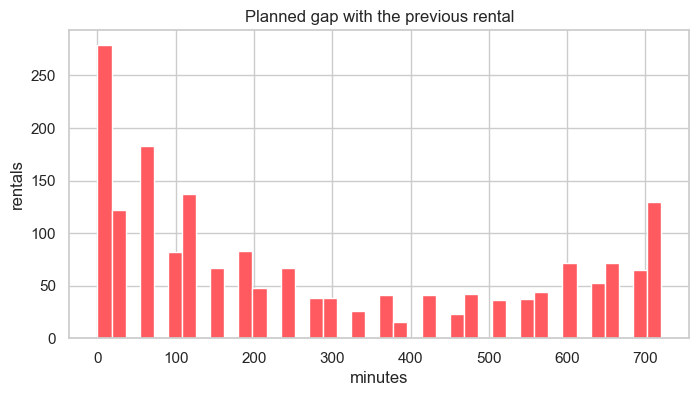

Median gap: 180 min


In [8]:
chained = delay[delay.previous_ended_rental_id.notna()]
print(f"Back-to-back rentals: {len(chained)} / {len(delay)} = {len(chained) / len(delay) * 100:.1f}%")

gap = chained["time_delta_with_previous_rental_in_minutes"].dropna()

plt.figure()
# No clipping here: the variable is naturally bounded, since
# previous_ended_rental_id is only populated when the previous rental ended
# within 12h. The gap cannot exceed 720 minutes.
plt.hist(gap, bins=40, color=ACCENT, edgecolor="white")
plt.title("Planned gap with the previous rental")
plt.xlabel("minutes")
plt.ylabel("rentals")
plt.show()

print(f"Median gap: {gap.median():.0f} min")

A median gap of roughly 180 minutes means half of all back-to-back rentals leave less than three hours of slack (buffer time). 

Any threshold in the 60–180 minute range therefore falls inside the bulk of the distribution rather than in its tail. How many bookings that would actually block is quantified by the dashboard's simulator.

### Check-in type against rental state

state         canceled  ended
checkin_type                 
connect          0.185  0.815
mobile           0.145  0.855


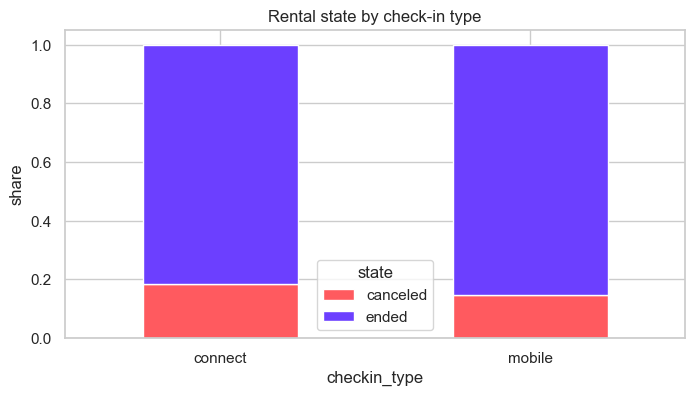

In [9]:
crosstab = pd.crosstab(delay.checkin_type, delay.state, normalize="index").round(3)
print(crosstab)

crosstab.plot.bar(stacked=True, color=[ACCENT, PRIMARY], rot=0)
plt.title("Rental state by check-in type")
plt.ylabel("share")
plt.legend(title="state")
plt.show()

---
## Part 2 — Pricing dataset

One row per car. The target is `rental_price_per_day`.

In [10]:
# The first column is an unnamed index (car number).
price = pd.read_csv(DATA / "get_around_pricing_project.csv", index_col=0)
print("Shape:", price.shape)
price.head()

Shape: (4843, 14)


,model_key,mileage,engine_power,fuel,paint_color,car_type,private_parking_available,has_gps,has_air_conditioning,automatic_car,has_getaround_connect,has_speed_regulator,winter_tires,rental_price_per_day
0,Citroën,140411,100,diesel,black,convertible,True,True,False,False,True,True,True,106
1,Citroën,13929,317,petrol,grey,convertible,True,True,False,False,False,True,True,264
2,Citroën,183297,120,diesel,white,convertible,False,False,False,False,True,False,True,101
3,Citroën,128035,135,diesel,red,convertible,True,True,False,False,True,True,True,158
4,Citroën,97097,160,diesel,silver,convertible,True,True,False,False,False,True,True,183


## 2.A — Decision-driving EDA

Each subsection below settles one choice in the modelling pipeline: what to clean, how to encode, which metric to report.

### 2.A.1 — Structure and types

Splitting the columns into numeric, categorical and boolean drives the whole preprocessing step.

In [11]:
price.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4843 entries, 0 to 4842
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   model_key                  4843 non-null   object
 1   mileage                    4843 non-null   int64 
 2   engine_power               4843 non-null   int64 
 3   fuel                       4843 non-null   object
 4   paint_color                4843 non-null   object
 5   car_type                   4843 non-null   object
 6   private_parking_available  4843 non-null   bool  
 7   has_gps                    4843 non-null   bool  
 8   has_air_conditioning       4843 non-null   bool  
 9   automatic_car              4843 non-null   bool  
 10  has_getaround_connect      4843 non-null   bool  
 11  has_speed_regulator        4843 non-null   bool  
 12  winter_tires               4843 non-null   bool  
 13  rental_price_per_day       4843 non-null   int64 
dtypes: bool(7), i

In [12]:
price.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
model_key,4843,28,Citroën,969,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage,4843.0,NaN,NaN,NaN,140962.799504,60196.740703,-64.0,102913.5,141080.0,175195.5,1000376.0
engine_power,4843.0,NaN,NaN,NaN,128.98823,38.99336,0.0,100.0,120.0,135.0,423.0
fuel,4843,4,diesel,4641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
paint_color,4843,10,black,1633,NaN,NaN,NaN,NaN,NaN,NaN,NaN
car_type,4843,8,estate,1606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
private_parking_available,4843,2,True,2662,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_gps,4843,2,True,3839,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_air_conditioning,4843,2,False,3865,NaN,NaN,NaN,NaN,NaN,NaN,NaN
automatic_car,4843,2,False,3881,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2.A.2 — Data quality

Three implausible rows to remove before training, so the model does not fit on noise.

In [13]:
print("negative mileage       :", (price.mileage < 0).sum(), "row(s)")
print("mileage above 1M       :", (price.mileage > 1_000_000).sum(), "row(s)")
print("engine_power = 0       :", (price.engine_power == 0).sum(), "row(s)")
print("missing values         :", int(price.isna().sum().sum()))

display(price[price.mileage < 0])
display(price[price.mileage > 1_000_000])

negative mileage       : 1 row(s)
mileage above 1M       : 1 row(s)
engine_power = 0       : 1 row(s)
missing values         : 0


,model_key,mileage,engine_power,fuel,paint_color,car_type,private_parking_available,has_gps,has_air_conditioning,automatic_car,has_getaround_connect,has_speed_regulator,winter_tires,rental_price_per_day
2938,Renault,-64,230,diesel,black,sedan,True,True,False,True,False,False,True,274


,model_key,mileage,engine_power,fuel,paint_color,car_type,private_parking_available,has_gps,has_air_conditioning,automatic_car,has_getaround_connect,has_speed_regulator,winter_tires,rental_price_per_day
3732,Citroën,1000376,90,diesel,black,subcompact,True,False,False,False,False,False,True,37


### 2.A.3 — Target distribution

A strongly right-skewed target would justify a log transform and would make RMSE a poor summary of the error. The cell below measures the skew instead of assuming it.

In [14]:
y = price.rental_price_per_day

# Three converging indicators of right skew:
# 1) mean vs median — a long upper tail pulls the mean above the median;
print(f"mean = {y.mean():.1f}  |  median = {y.median():.1f}")

# 2) skewness — 0 is symmetric, > 1 clearly right-skewed;
print(f"skewness = {y.skew():.2f}")

# 3) percentiles and the real weight of the tail.
print("percentiles:", {f"p{p}": round(y.quantile(p / 100)) for p in [1, 5, 25, 50, 75, 95, 99]})
print(f"max = {y.max()}  |  cars above 250 €: {(y > 250).sum()} ({(y > 250).mean() * 100:.2f}%)")

mean = 121.2  |  median = 119.0
skewness = 0.62
percentiles: {'p1': 28, 'p5': 70, 'p25': 104, 'p50': 119, 'p75': 136, 'p95': 182, 'p99': 216}
max = 422  |  cars above 250 €: 15 (0.31%)


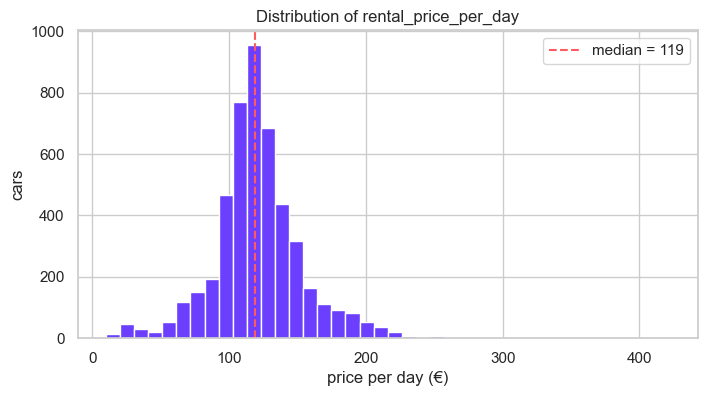

{'count': 4843.0, 'mean': 121.2, 'std': 33.6, 'min': 10.0, '25%': 104.0, '50%': 119.0, '75%': 136.0, 'max': 422.0}


In [15]:
plt.figure()
plt.hist(y, bins=40, color=PRIMARY, edgecolor="white")
plt.axvline(y.median(), color=ACCENT, ls="--", label=f"median = {y.median():.0f}")
plt.title("Distribution of rental_price_per_day")
plt.xlabel("price per day (€)")
plt.ylabel("cars")
plt.legend()
plt.show()

print(y.describe().round(1).to_dict())

Skewness of 0.61 with mean and median 2 € apart: the distribution is close to symmetric and the wide axis comes from a handful of extreme values (0.29% of cars above 250 €). A log transform is not obviously justified — notebook 02 tests it rather than settling the question here.

### 2.A.4 — Categorical cardinality

Cardinality decides the encoding strategy: few levels means straightforward one-hot encoding, many levels (`model_key`) means a wide sparse matrix and raises the question of grouping rare categories.

             n_levels top_level  top_share_%
model_key          28   Citroën         20.0
fuel                4    diesel         95.8
paint_color        10     black         33.7
car_type            8    estate         33.2


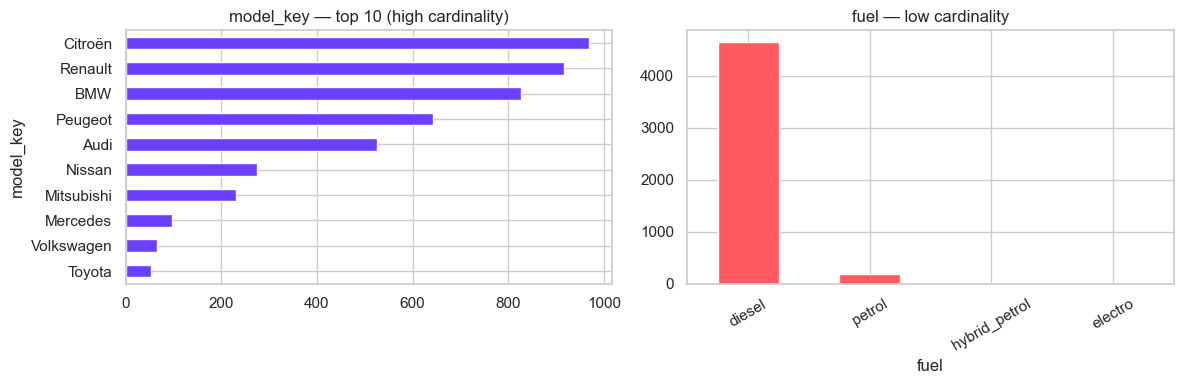

In [16]:
cat_cols = ["model_key", "fuel", "paint_color", "car_type"]

cardinality = pd.DataFrame(
    {
        "n_levels": [price[c].nunique() for c in cat_cols],
        "top_level": [price[c].value_counts().index[0] for c in cat_cols],
        "top_share_%": [round(price[c].value_counts(normalize=True).iloc[0] * 100, 1) for c in cat_cols],
    },
    index=cat_cols,
)
print(cardinality)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
price.model_key.value_counts().head(10).plot.barh(ax=axes[0], color=PRIMARY)
axes[0].set_title("model_key — top 10 (high cardinality)")
axes[0].invert_yaxis()
price.fuel.value_counts().plot.bar(ax=axes[1], color=ACCENT, rot=30)
axes[1].set_title("fuel — low cardinality")
plt.tight_layout()
plt.show()

**Conclusions for the pipeline:** drop the three implausible rows; separate numeric / categorical / boolean columns, one-hot encode the categoricals (`model_key` alone accounts for most of the resulting width, which is worth keeping in mind when reading feature importances); standardise the numeric columns for the linear baseline; and report RMSE alongside MAE.

## 2.B — Interpretation EDA

Nothing below changes the pipeline: the booleans are already 0/1 and a tree-based model is indifferent to linear correlation. These sections exist to help read the results i.e. to make the model's feature importances readable after training.

### 2.B.1 — Boolean options against price

For each option: share of cars equipped, and mean price with and without it.

In [17]:
bool_cols = [
    "private_parking_available", "has_gps", "has_air_conditioning",
    "automatic_car", "has_getaround_connect", "has_speed_regulator", "winter_tires",
]

options = pd.DataFrame([
    {
        "option": c,
        "% equipped": round(price[c].mean() * 100, 1),
        "mean price with": round(price.loc[price[c], "rental_price_per_day"].mean(), 1),
        "mean price without": round(price.loc[~price[c], "rental_price_per_day"].mean(), 1),
    }
    for c in bool_cols
])
options["gap €"] = (options["mean price with"] - options["mean price without"]).round(1)
options.sort_values("gap €", ascending=False)

,option,% equipped,mean price with,mean price without,gap €
3,automatic_car,19.9,149.5,114.2,35.3
1,has_gps,79.3,126.6,100.8,25.8
4,has_getaround_connect,46.0,132.8,111.3,21.5
2,has_air_conditioning,20.2,137.6,117.1,20.5
0,private_parking_available,55.0,129.8,110.8,19.0
5,has_speed_regulator,24.1,134.8,116.9,17.9
6,winter_tires,93.2,121.4,118.9,2.5


### 2.B.2 — Numeric variables against price

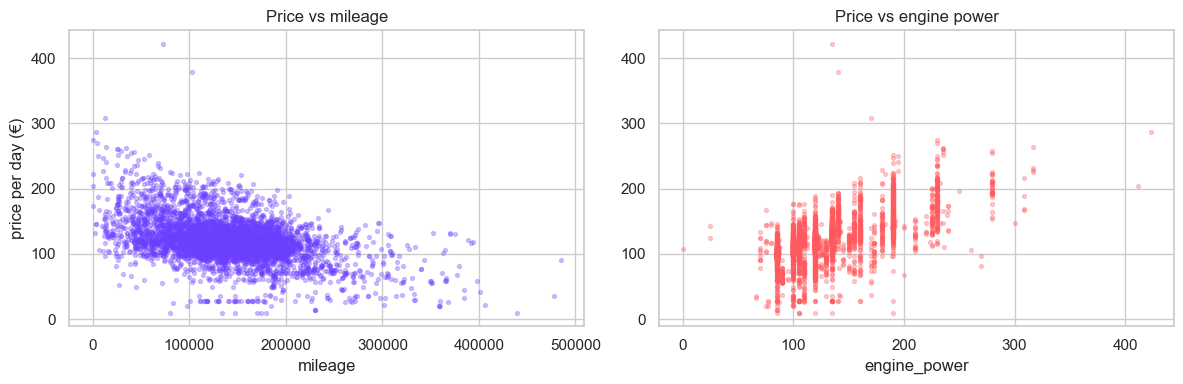

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plausible = price[price.mileage < 1_000_000]  # hide the outlier for readability
axes[0].scatter(plausible.mileage, plausible.rental_price_per_day, s=8, alpha=0.3, color=PRIMARY)
axes[0].set_title("Price vs mileage")
axes[0].set_xlabel("mileage")
axes[0].set_ylabel("price per day (€)")

axes[1].scatter(price.engine_power, price.rental_price_per_day, s=8, alpha=0.3, color=ACCENT)
axes[1].set_title("Price vs engine power")
axes[1].set_xlabel("engine_power")

plt.tight_layout()
plt.show()

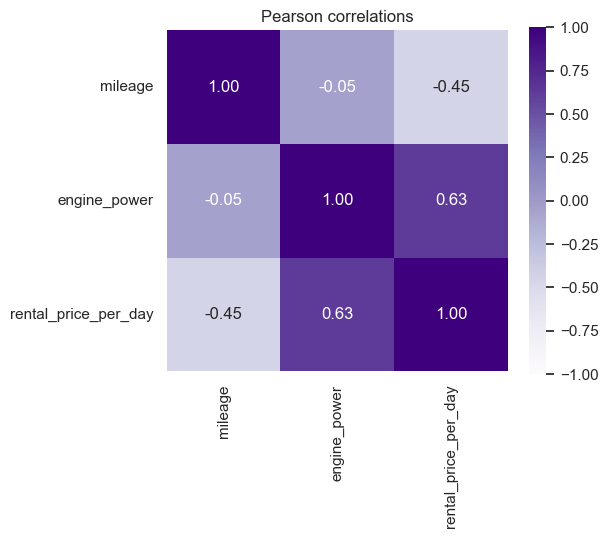

In [19]:
numeric = plausible[["mileage", "engine_power", "rental_price_per_day"]]

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(numeric.corr(), annot=True, cmap="Purples", vmin=-1, vmax=1, fmt=".2f", square=True)
plt.title("Pearson correlations")
plt.show()

### 2.B.3 — Mean price by category

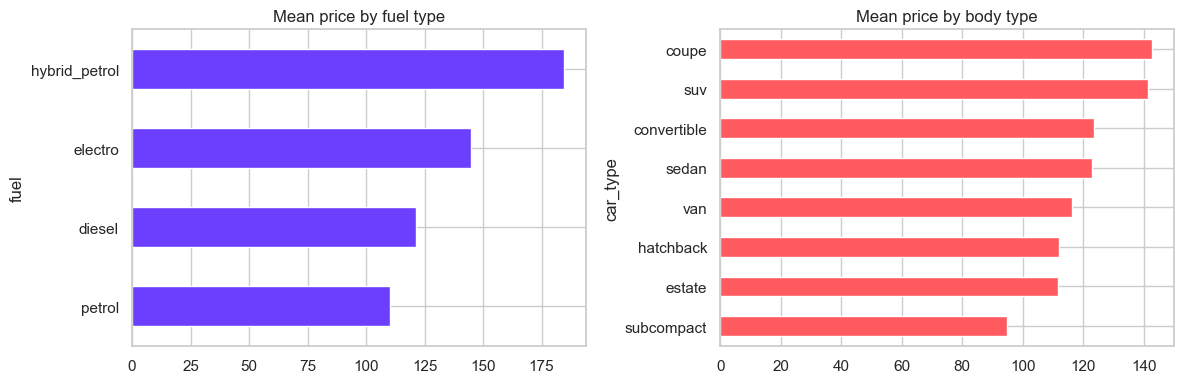

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

price.groupby("fuel").rental_price_per_day.mean().sort_values().plot.barh(ax=axes[0], color=PRIMARY)
axes[0].set_title("Mean price by fuel type")

price.groupby("car_type").rental_price_per_day.mean().sort_values().plot.barh(ax=axes[1], color=ACCENT)
axes[1].set_title("Mean price by body type")

plt.tight_layout()
plt.show()

---
## Summary

**Delay dataset (dashboard)**

- ~85% `ended` / ~15% `canceled`; ~80% `mobile` / ~20% `connect`.
- ~57% of returns are late, median lateness ~53 min, with extreme outliers to clip for display.
- Only ~9% of rentals are back-to-back — the ceiling on what a minimum-delay rule can reach.

**Pricing dataset**

| Section | Decision it drives |
|---|---|
| 2.A.1 Structure | column typing for the preprocessing step |
| 2.A.2 Quality | drop mileage < 0, mileage > 1M, engine_power = 0 |
| 2.A.3 Target | metric choice; log transform to be tested, not assumed |
| 2.A.4 Cardinality | one-hot encoding, with `model_key` as the wide one |
| 2.B.1 Booleans | reading of "which options are worth money" |
| 2.B.2 Numerics | reading of `engine_power` / `mileage` importances |
| 2.B.3 Categories | reading of brand / body / fuel importances |

Next: cleaning, preprocessing pipeline, model training and MLflow tracking in `02_price_modelling.ipynb`.